# 📊 Análisis de las Tiendas Alura Store

**Autor:** Rogelio Leonardo Méndez Macías  
**LinkedIn:** [Perfil profesional](https://www.linkedin.com/in/rogelio-leonardo-mendez-macias-6286851ab/)  
**Fecha:** 30 de abril de 2025


**Desafio:**

Ayudar al Sr. Juan a decidir qué tienda de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento. Para ello, analizarás datos de ventas, rendimiento y reseñas de las 4 tiendas de Alura Store. El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.

**Requisitos:**

1. **Análisis de datos**  
   - Ingresos  
   - Categorías más vendidas  
   - Reseñas de clientes  
   - Productos más vendidos  
   - Tiempo promedio de envío

2. **Visualización de resultados**  
   - Usar gráficos de barras, circulares, de dispersión, etc.  
   - Incluir al menos 3 tipos de gráficos

3. **Recomendación final**  
   - Explicar qué tienda vender y por qué, con base en los datos.

### Importación de datos



In [19]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [20]:
#Librerías
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

In [22]:
#Unir todos DataFrames
df = pd.concat([tienda,tienda2,tienda3,tienda4], ignore_index=True)
df.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


In [23]:
#Convertimos la fecha y calculamos ingresos
df["Fecha de Compra"] = pd.to_datetime(df['Fecha de Compra'])
df["Ingresos"] = df['Precio']+df['Costo de envío']

<ipython-input-23-8c0c4c32dcba>:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Fecha de Compra"] = pd.to_datetime(df['Fecha de Compra'])


In [24]:
#Verificamos la estructura final
df.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda,Ingresos
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1,171200.0
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1,200700.0
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1,225500.0
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1,798500.0
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1,355400.0


#1. Análisis de facturación



[Documentación pandas.DataFrame.groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)

In [25]:
#Agrupar por tienada y sumar los ingresos
facturacion = df.groupby("Tienda")["Ingresos"].sum().sort_values(ascending=False)



In [27]:
# Mostrar los resultados numéricos
print("Facturación total por tienda:\n")
print(facturacion)

Facturación total por tienda:

Tienda
Tienda 1    1.212258e+09
Tienda 2    1.175829e+09
Tienda 3    1.156536e+09
Tienda 4    1.093693e+09
Name: Ingresos, dtype: float64


<ipython-input-29-4b1464228c57>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=facturacion.index, y=facturacion.values, palette="viridis")


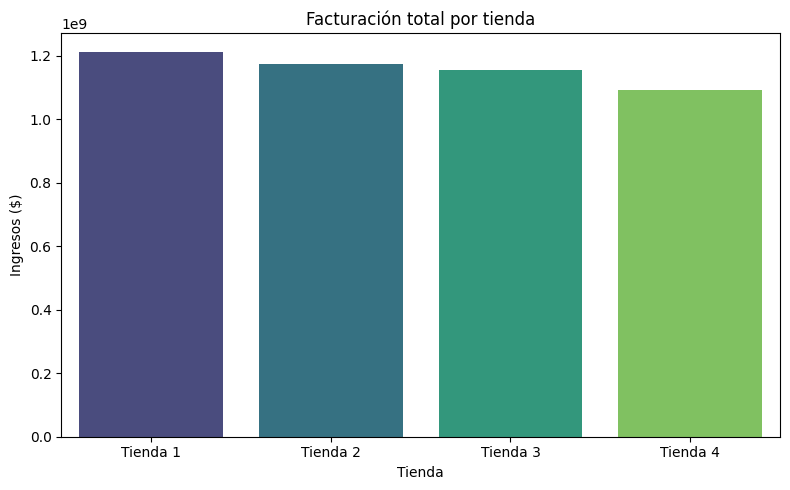

In [29]:
#Gráfico circular: Proporción de ingresos por tienda
plt.figure(figsize=(8, 5))
sns.barplot(x=facturacion.index, y=facturacion.values, palette="viridis")
plt.title("Facturación total por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingresos ($)")
plt.tight_layout()
plt.show()

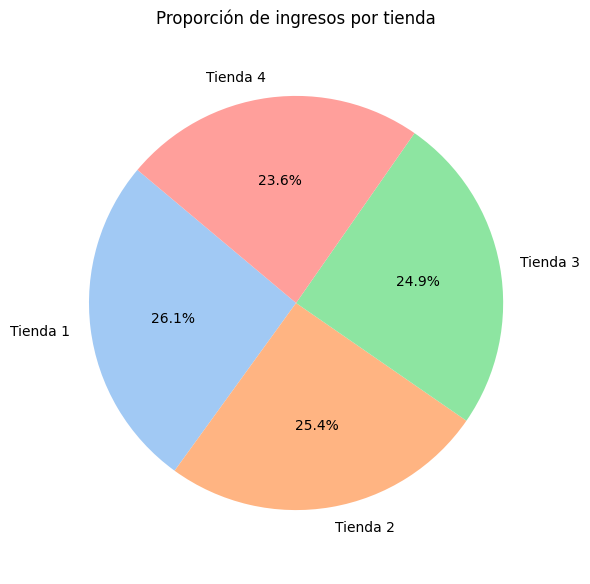

In [30]:
#Gráfico circular: Proporción de ingresos por tienda
plt.figure(figsize=(6, 6))
plt.pie(facturacion, labels=facturacion.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción de ingresos por tienda")
plt.axis('equal')
plt.tight_layout()
plt.show()


<ipython-input-31-36db7b7ff0c2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Tienda", y="Ingresos", jitter=True, palette="Set2", alpha=0.6)


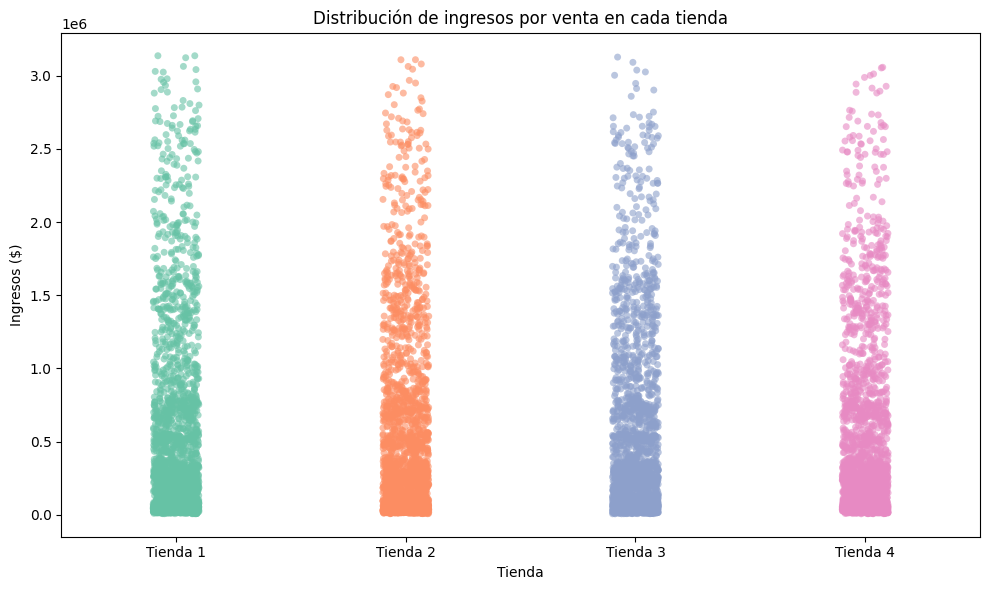

In [31]:
#Gráfico de dispersión: Ingresos individuales por tienda
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x="Tienda", y="Ingresos", jitter=True, palette="Set2", alpha=0.6)
plt.title("Distribución de ingresos por venta en cada tienda")
plt.ylabel("Ingresos ($)")
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [36]:
#Agrupar por tienada y sumar los ingresos
ventas_por_categoria = df.groupby("Categoría del Producto")["Ingresos"].sum().sort_values(ascending=False)

In [37]:
#Mostrar resultados
print("Ventas por categoria:\n")
print(ventas_por_categoria)

Ventas por categoria:

Categoría del Producto
Electrónicos               1.749039e+09
Electrodomésticos          1.395147e+09
Muebles                    7.981114e+08
Instrumentos musicales     3.672769e+08
Deportes y diversión       1.506693e+08
Juguetes                   7.762570e+07
Artículos para el hogar    6.069090e+07
Libros                     3.975600e+07
Name: Ingresos, dtype: float64


<ipython-input-38-17a5b2e110ca>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, palette="viridis")


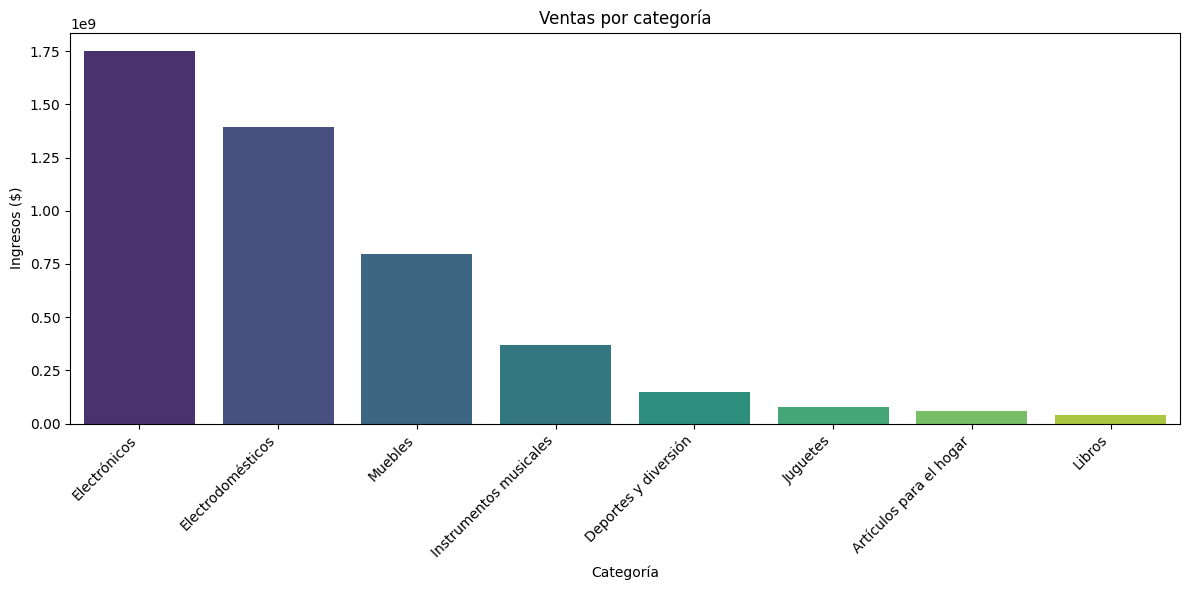

In [38]:
# Gráfico de barras: Ventas por categoría
plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, palette="viridis")
plt.title("Ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()
plt.show()

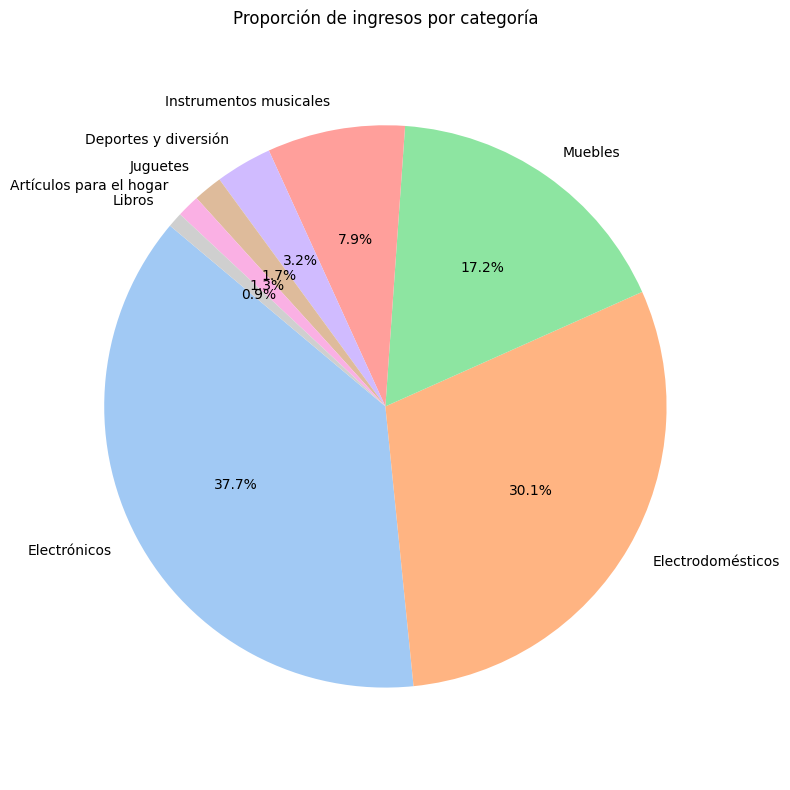

In [39]:
# Gráfico circular: Proporción de ingresos por categoría
plt.figure(figsize=(8, 8))
plt.pie(ventas_por_categoria, labels=ventas_por_categoria.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción de ingresos por categoría")
plt.axis('equal')  # Para asegurar que el círculo sea un círculo
plt.tight_layout()
plt.show()

In [41]:
import plotly.express as px

# Gráfico de dispersión interactivo: Ventas por categoría y tienda
fig = px.scatter(df, x="Categoría del Producto", y="Ingresos", color="Tienda",
                 hover_data=['Categoría del Producto', 'Ingresos', 'Tienda'],
                 title="Distribución de ingresos por categoría y tienda")
fig.show()

# 3. Calificación promedio de la tienda


In [42]:
calificacion_promedio = df.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)

In [43]:
# Mostrar resultados numéricos
print("Calificación promedio por tienda:\n")
print(calificacion_promedio)

Calificación promedio por tienda:

Tienda
Tienda 3    4.048326
Tienda 2    4.037304
Tienda 4    3.995759
Tienda 1    3.976685
Name: Calificación, dtype: float64


<ipython-input-44-d4593c2d3775>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




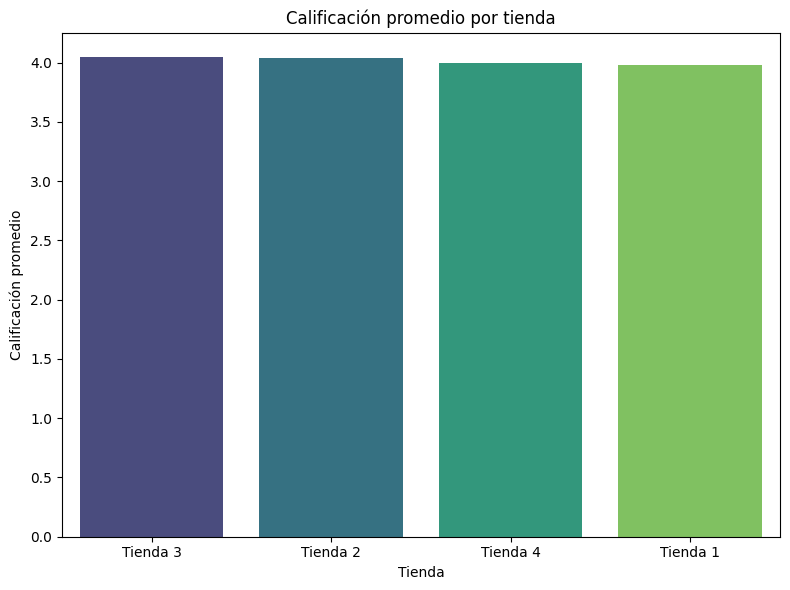

In [44]:
# Gráfico de barras: Calificación promedio por tienda
plt.figure(figsize=(8, 6))
sns.barplot(x=calificacion_promedio.index, y=calificacion_promedio.values, palette="viridis")
plt.title("Calificación promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación promedio")
plt.tight_layout()
plt.show()

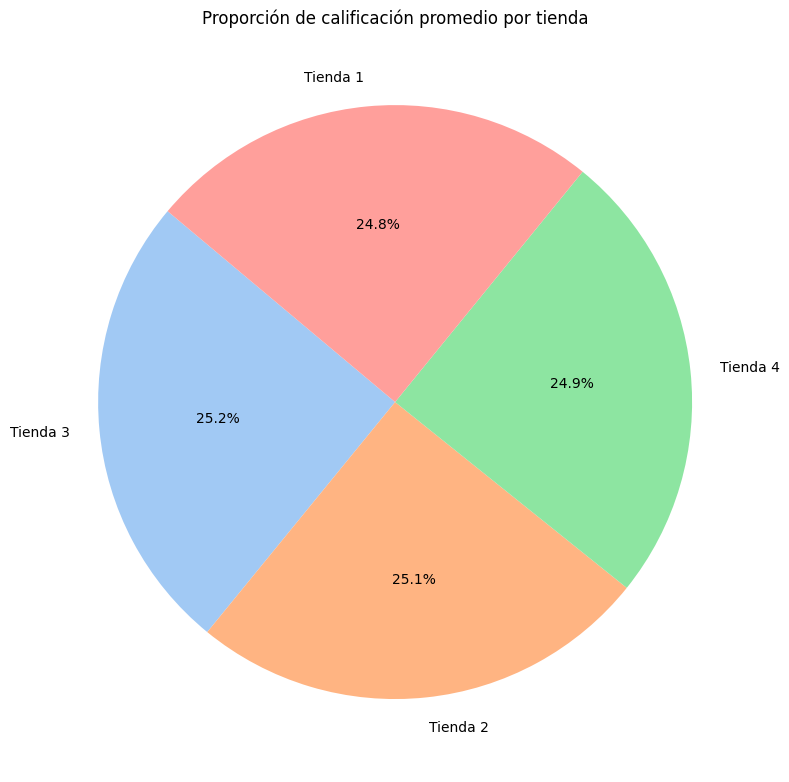

In [45]:
# Gráfico circular: Proporción de calificación promedio por tienda
plt.figure(figsize=(8, 8))
plt.pie(calificacion_promedio, labels=calificacion_promedio.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción de calificación promedio por tienda")
plt.axis('equal')  # Para asegurar que el círculo sea un círculo
plt.tight_layout()
plt.show()

<ipython-input-48-09738cbedb72>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




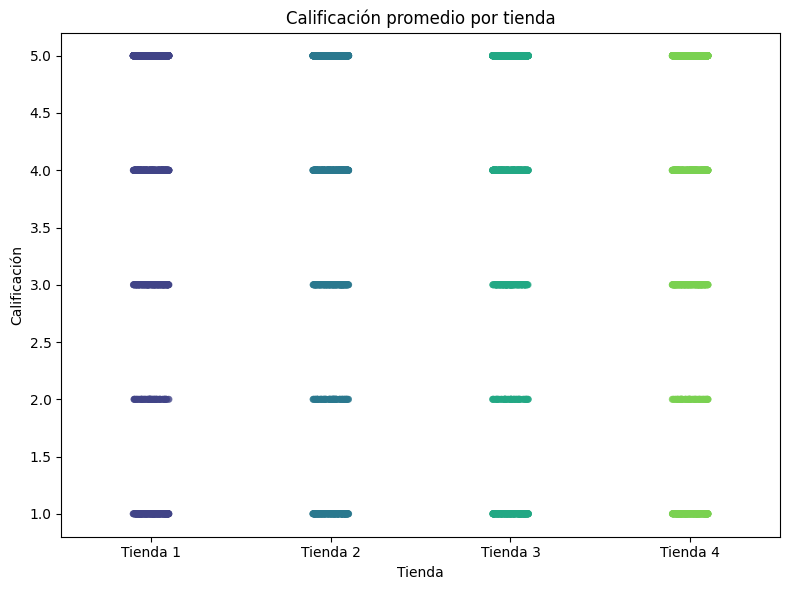

In [48]:
# Gráfico stripplot: Calificación promedio por tienda
plt.figure(figsize=(8, 6))
sns.stripplot(x='Tienda', y='Calificación', data=df, jitter=True, palette="viridis", alpha=0.6)
plt.title("Calificación promedio por tienda")
plt.ylabel("Calificación")
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [51]:
#Agrupar los productos mas vendidos y los menos vendido
productos_vendidos = df.groupby("Producto")["Ingresos"].mean().sort_values(ascending=False)

In [52]:
# Mostrar los 10 productos más vendidos
print("Los 10 productos más vendidos:\n")
print(productos_vendidos.head(10))

Los 10 productos más vendidos:

Producto
TV LED UHD 4K         2.435960e+06
Iphone 15             2.133564e+06
Refrigerador          2.122476e+06
Smart TV              1.591993e+06
Lavadora de ropa      1.450894e+06
Lavavajillas          1.340451e+06
Tablet ABXY           1.288945e+06
Secadora de ropa      1.107161e+06
Celular ABXY          1.059381e+06
Guitarra eléctrica    8.258297e+05
Name: Ingresos, dtype: float64


In [53]:
# Mostrar los 10 productos menos vendidos
print("\nLos 10 productos menos vendidos:\n")
print(productos_vendidos.tail(10))


Los 10 productos menos vendidos:

Producto
Muñeca bebé                51448.571429
Vaso térmico               47847.058824
Cubertería                 47510.052910
Dashboards con Power BI    37555.801105
Bloques de construcción    35836.683417
Set de vasos               35184.615385
Ajedrez de madera          30136.111111
Dinosaurio Rex             19257.714286
Cuerda para saltar         17916.129032
Cubo mágico 8x8            16344.444444
Name: Ingresos, dtype: float64


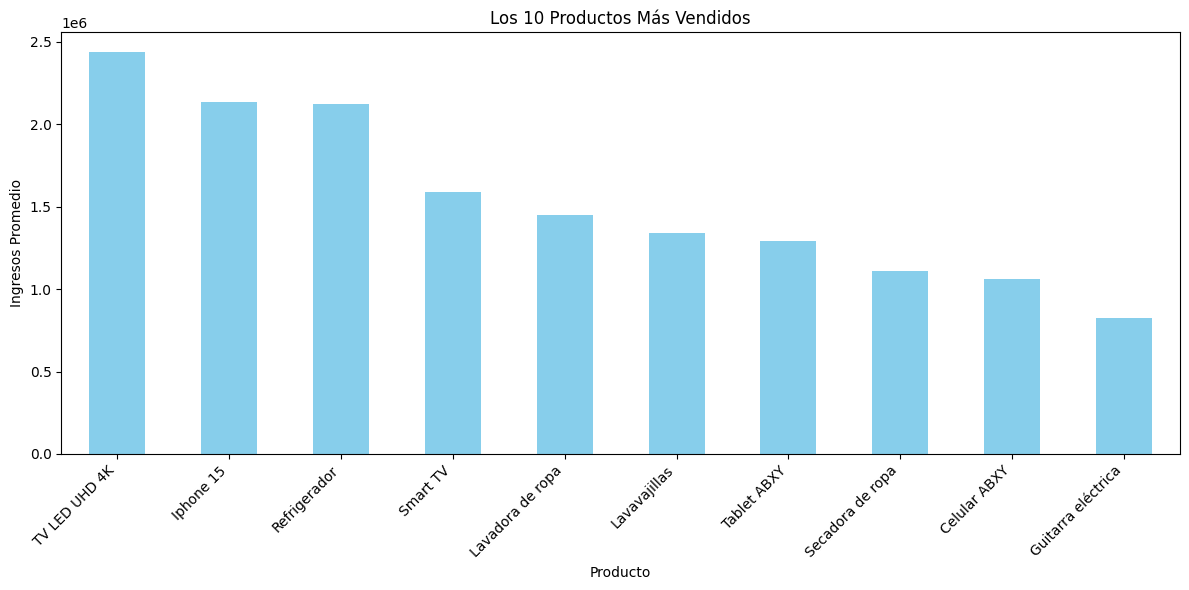

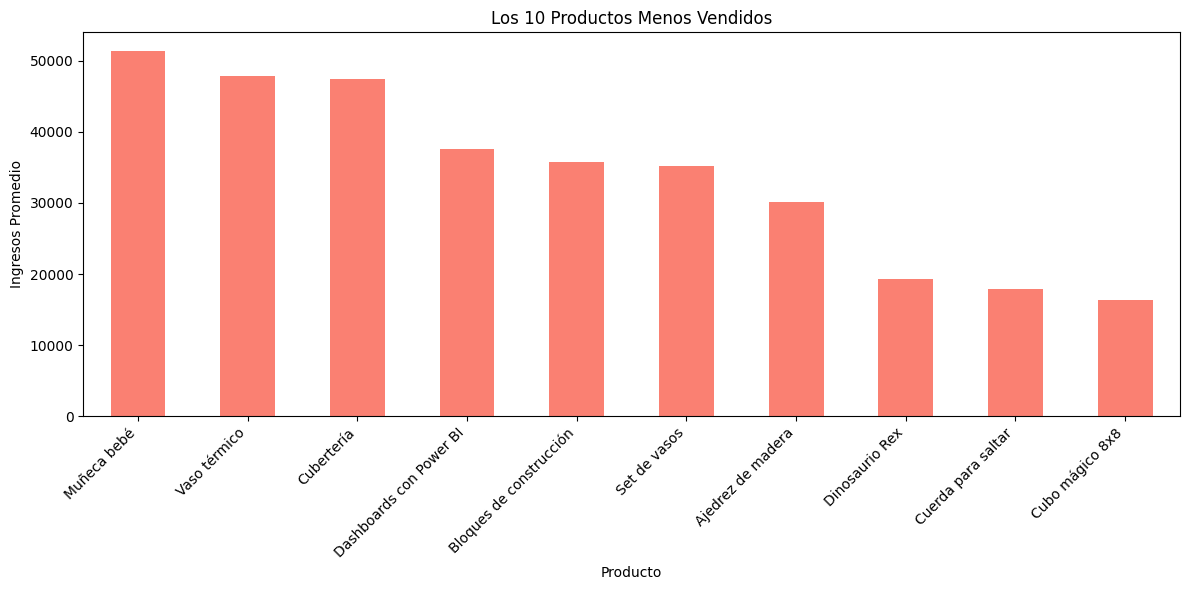

In [55]:
# Gráfico de barras: Los 10 productos más vendidos
plt.figure(figsize=(12, 6))
productos_vendidos.head(10).plot(kind='bar', color='skyblue')
plt.title('Los 10 Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Ingresos Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico de barras: Los 10 productos menos vendidos
plt.figure(figsize=(12, 6))
productos_vendidos.tail(10).plot(kind='bar', color='salmon')
plt.title('Los 10 Productos Menos Vendidos')
plt.xlabel('Producto')
plt.ylabel('Ingresos Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


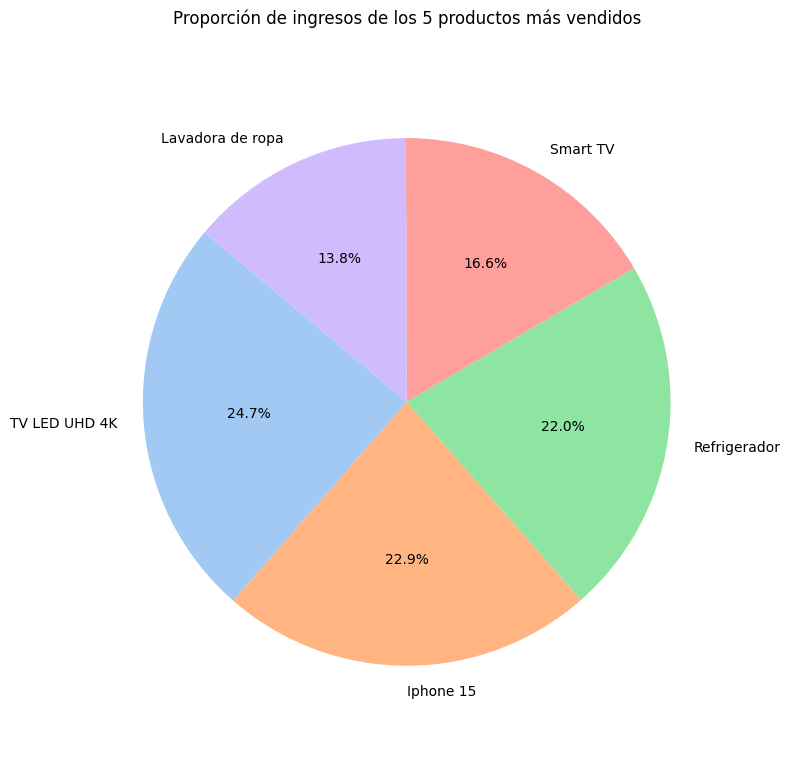

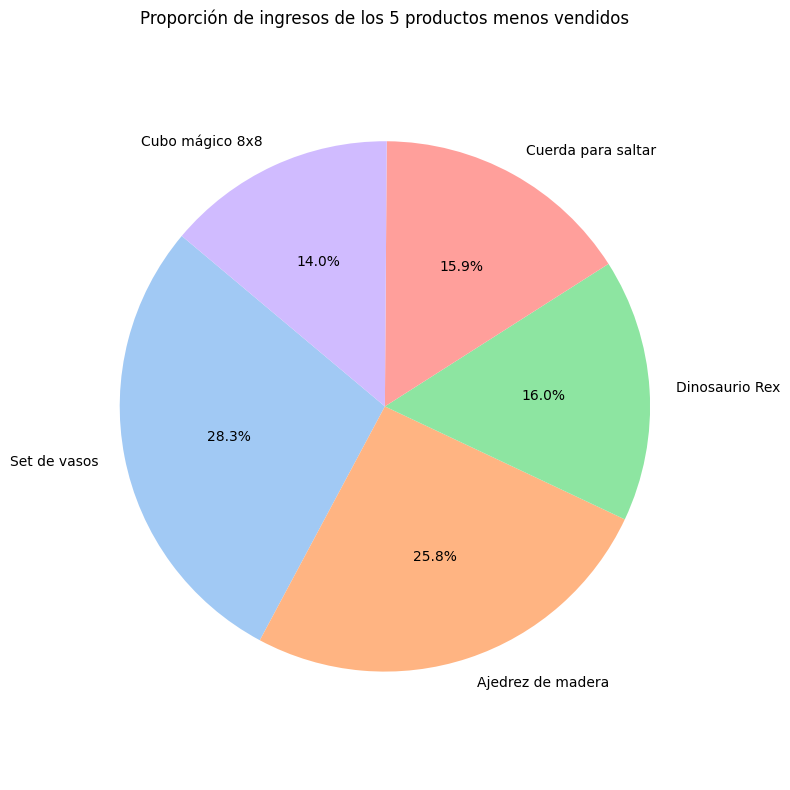

In [56]:
# Gráfico de pastel: Productos más y menos vendidos
productos_vendidos = df.groupby("Producto")["Ingresos"].sum().sort_values(ascending=False)

# Seleccionar los 5 productos más y menos vendidos
top_products = productos_vendidos.head(5)
bottom_products = productos_vendidos.tail(5)

# Crear el gráfico de pastel para los productos más vendidos
plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción de ingresos de los 5 productos más vendidos")
plt.axis('equal')
plt.tight_layout()
plt.show()

# Crear el gráfico de pastel para los productos menos vendidos
plt.figure(figsize=(8, 8))
plt.pie(bottom_products, labels=bottom_products.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción de ingresos de los 5 productos menos vendidos")
plt.axis('equal')
plt.tight_layout()
plt.show()


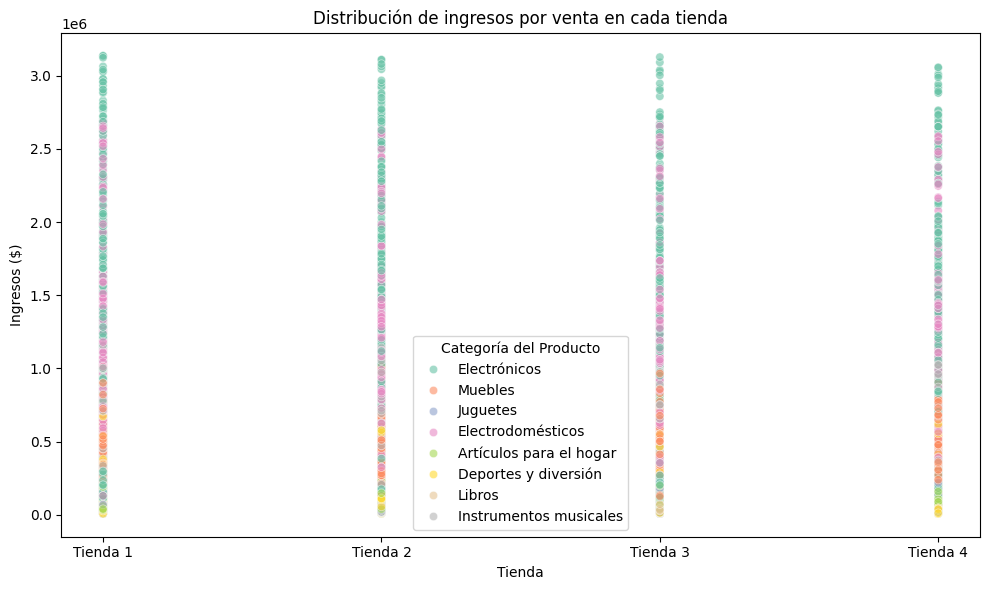

In [57]:
# Gráfico de dispersión: Ingresos individuales por tienda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Tienda", y="Ingresos", hue="Categoría del Producto", palette="Set2", alpha=0.6)
plt.title("Distribución de ingresos por venta en cada tienda")
plt.ylabel("Ingresos ($)")
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()


# 5. Envío promedio por tienda

In [58]:
# Agrupar por tienda y calcular el envío promedio
envio_promedio = df.groupby('Tienda')['Costo de envío'].mean().sort_values(ascending=False)


In [59]:
# Mostrar resultados numéricos
print("Envío promedio por tienda:\n")
print(envio_promedio)


Envío promedio por tienda:

Tienda
Tienda 1    26018.609580
Tienda 2    25216.235693
Tienda 3    24805.680373
Tienda 4    23459.457167
Name: Costo de envío, dtype: float64


<ipython-input-60-dc4d181f66bd>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




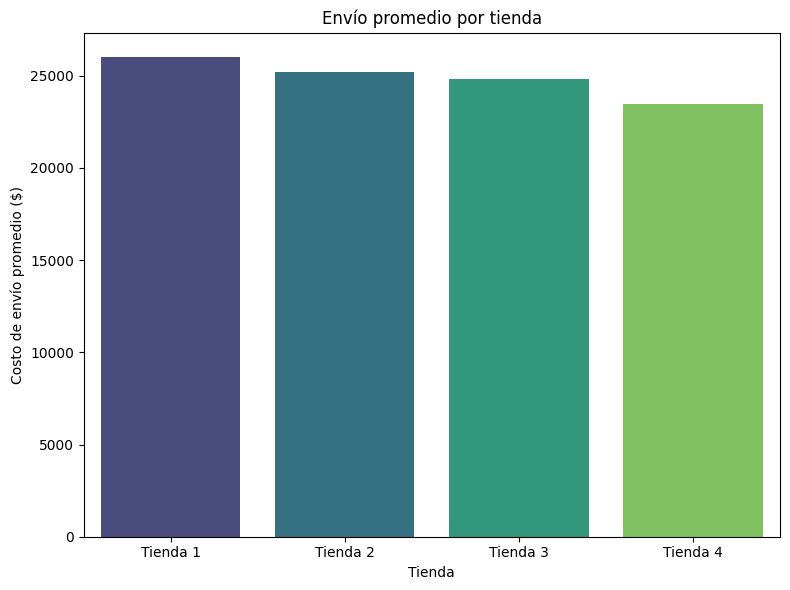

In [60]:
# Gráfico de barras: Envío promedio por tienda
plt.figure(figsize=(8, 6))
sns.barplot(x=envio_promedio.index, y=envio_promedio.values, palette="viridis")
plt.title("Envío promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Costo de envío promedio ($)")
plt.tight_layout()
plt.show()

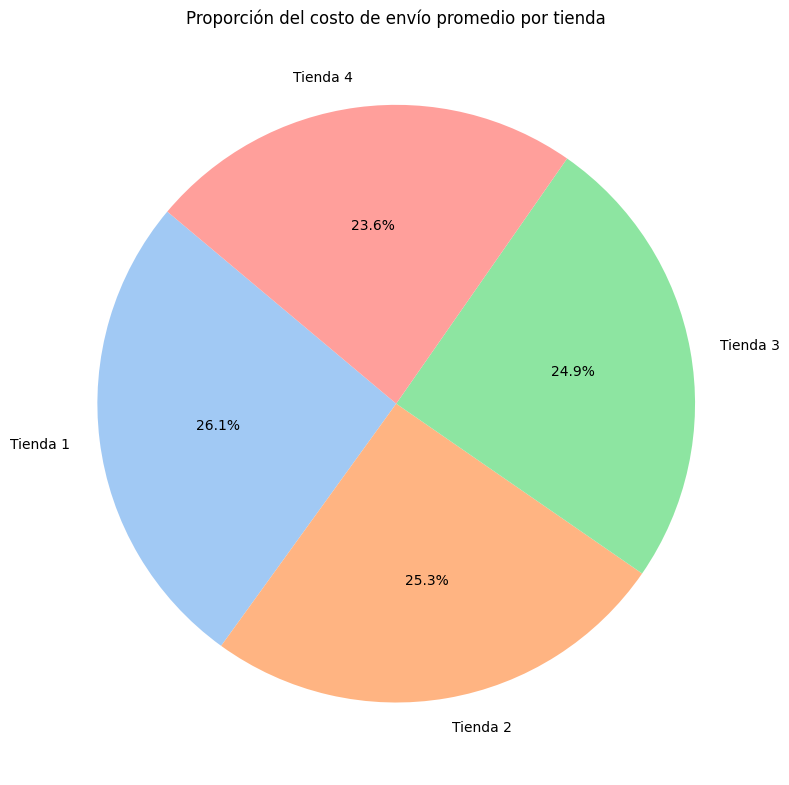

In [62]:
# Gráfico de pastel: Envío promedio por tienda
plt.figure(figsize=(8, 8))
plt.pie(envio_promedio, labels=envio_promedio.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proporción del costo de envío promedio por tienda")
plt.axis('equal')  # Para asegurar que el círculo sea un círculo
plt.tight_layout()
plt.show()


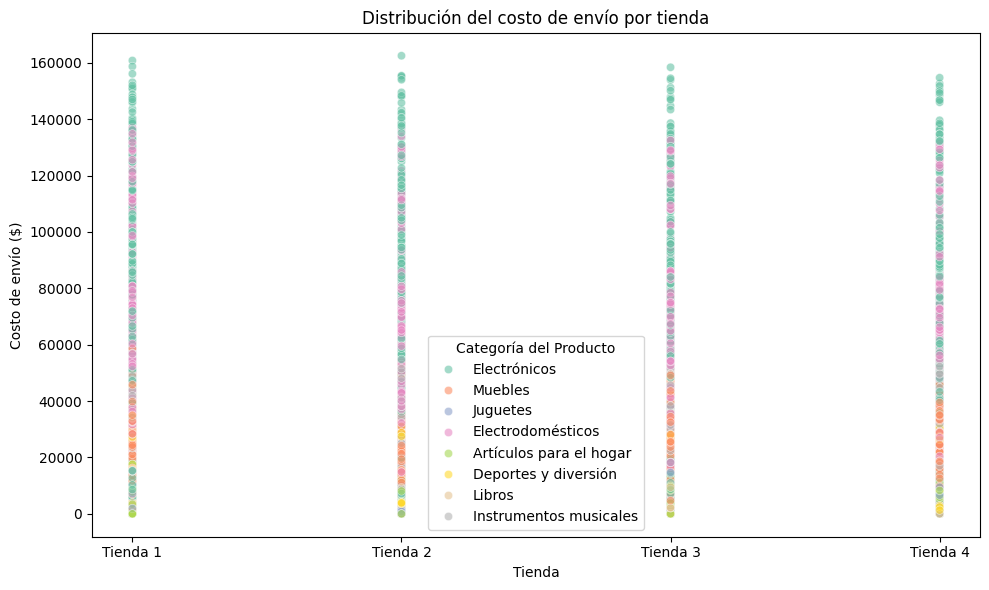

In [63]:
# Gráfico de dispersión: Envío promedio por tienda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Tienda", y="Costo de envío", hue="Categoría del Producto", palette="Set2", alpha=0.6)
plt.title("Distribución del costo de envío por tienda")
plt.ylabel("Costo de envío ($)")
plt.xlabel("Tienda")
plt.tight_layout()
plt.show()


## Conclusión
Después de analizar los datos de facturación, calificación promedio, costo de envío promedio y ventas por categoría de las cuatro tiendas Alura Store, se ha identificado que la tienda 4 presenta el rendimiento más bajo en comparación con las demás.

La tienda 4 tiene la menor facturación total, lo que indica un menor volumen de ventas y, por lo tanto, menor rentabilidad. Además, su calificación promedio es la más baja, lo que sugiere una menor satisfacción del cliente. Si bien el costo de envío promedio es el más bajo, esto podría ser una desventaja competitiva si las otras tiendas ofrecen envíos más rápidos o económicos.
## 📌 Recomendación Final
Con base en los hallazgos del análisis, se recomienda al Sr. Juan considerar la venta de la tienda 4. Esta tienda presenta indicadores de bajo rendimiento en comparación con las otras tiendas de la cadena Alura Store, lo que justifica su selección como la menos eficiente. Sin embargo, se recomienda realizar un análisis más profundo de las ventas por categoría y productos en la tienda 4 antes de tomar una decisión final. Si este análisis adicional confirma la baja eficiencia de la tienda 4, se recomienda proceder con su venta.